# Yermolaev HSS event analysis

## tl;dr

For 2018, 31 of 61 Yermolaev HSS systems have an associated leading CIR; 29 of those systems pass the data-coverage criterion. Expanding the detection window to the full CIR–HSS system detects 30 of 45 eligible events overall (66.7%) and 21 of 29 eligible CIR-associated events (72.4%). The one-to-one assignments and speed results are unchanged from the `SWfast`-only definition because the existing ±24-hour tolerance already selected the same predicted streams. Among detected CIR systems, the modeled 450 km/s onset is a median 1 hour before the catalog CIR start, and 6 onsets fall inside the catalogued CIR interval. P20 remains restricted to `SWfast` hours: detected events have a mean/median underprediction of 72.3/77.4 km/s, versus 152.0/154.1 km/s for misses.


## Context & Methods

The analysis answers two first-pass questions:

1. Which Yermolaev `SWfast` intervals and leading CIRs belong to the same CIR–HSS system?
2. Conditional on helio-n predicting an HSS at all, by how much does it underpredict the event's 20th-percentile speed?

### Key assumptions

- The Yermolaev catalog is an OMNI/Earth classification, so the comparison is restricted to ACE/Earth.
- `SWfast` is the catalog HSS label. Consecutive `SWfast` blocks are one event when every intervening row is shock/sheath/ejecta/MC-related (`IS`, `ISa`, `SHE`, `EJE`, or `MC`, including `?` variants).
- `CIR` remains a separator between successive fast streams: it never bridges a preceding `SWfast` block to a following one. A leading `CIR → [IS/ISa] → SWfast` sequence is instead attached to the following HSS as its interaction region.
- `SWslow` is never a bridge. Any other non-bridge type also closes the event.
- CIR and bridged hours expand the event envelope used for detection and timing, but do not enter the speed metric: percentile calculations use only hours explicitly labeled `SWfast`.
- Catalog end hours are inclusive. They are converted to half-open intervals by adding one hour.
- The model series is raw `v_predict_raw`. ACE observations are reloaded from `Data/ACE At Earth 1h.parquet` to preserve native gaps.
- A predicted HSS is a contiguous run of hourly `v_predict_raw` at or above a configurable threshold, currently 450 km/s.
- Detection uses one-to-one matching between catalog and predicted events. A match may overlap the catalog event envelope expanded by ±24 hours; matching maximizes the number of unique pairs, then prefers overlap and smaller gaps.
- P20 bias among detections and miss severity both use paired model/observation hours from the original catalog `SWfast` intervals, without shifting the speed series. Positive values mean the model is too slow.


## Data

### Imports and repository paths


In [1]:
from io import StringIO
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from scipy.optimize import linear_sum_assignment

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "Library").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
assert (PROJECT_ROOT / "Library").exists(), (
    "Run this notebook from the repository root or the Analysis directory"
)


/Users/aosh/.matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /private/tmp/matplotlib-bdvz0enm because there was an issue with the default path (/Users/aosh/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.



Fontconfig error: No writable cache directories
	/opt/homebrew/var/cache/fontconfig
	/Users/aosh/.cache/fontconfig
	/Users/aosh/.fontconfig



Fontconfig error: No writable cache directories
	/opt/homebrew/var/cache/fontconfig
	/Users/aosh/.cache/fontconfig
	/Users/aosh/.fontconfig



Fontconfig error: No writable cache directories
	/opt/homebrew/var/cache/fontconfig
	/Users/aosh/.cache/fontconfig
	/Users/aosh/.fontconfig

Fontconfig error: No writable cache directories
	/opt/homebrew/var/cache/fontconfig
	/Users/aosh/.cache/fontconfig
	/Users/aosh/.fontconfig



Fontconfig error: No writable cache directories
	/opt/homebrew/var/cache/fontconfig
	/Users/aosh/.cache/fontconfig
	/Users/aosh/.fontconfig


Matplotlib is building the font cache; this may take a moment.


### Analysis controls

Keep the event-definition and draft metric choices in one place so they can be revised without changing the calculation cells.


In [2]:
START_DT = pd.Timestamp("2018-01-01 00:00:00")
END_DT = pd.Timestamp("2019-01-01 00:00:00")

CATALOG_URL_TEMPLATE = "http://www.iki.rssi.ru/pub/omni/catalog/{year}/{year}int.txt"
CATALOG_FAST_TYPE = "SWfast"
CATALOG_BRIDGE_TYPES = {"IS", "ISa", "SHE", "EJE", "MC"}
CATALOG_CIR_TYPE = "CIR"
CATALOG_CIR_TO_FAST_TYPES = {"IS", "ISa"}

SPEED_QUANTILE = 0.20
PREDICTED_HSS_THRESHOLD_KMS = 450.0
DETECTION_TOLERANCE_HOURS = 24
MIN_PAIRED_HOURS = 6

STAMP = f"{START_DT:%Y%m%d_%H%M}-{END_DT:%Y%m%d_%H%M}"
REPRODUCTION_PATH = (
    PROJECT_ROOT / "Outputs/SW" / f"SW Reproduction Series {STAMP}.parquet"
)
ACE_PATH = PROJECT_ROOT / "Data/ACE At Earth 1h.parquet"

{
    "analysis_interval": f"[{START_DT}, {END_DT})",
    "reproduction_path": REPRODUCTION_PATH,
    "ace_path": ACE_PATH,
    "bridge_types": sorted(CATALOG_BRIDGE_TYPES),
    "cir_to_fast_types": sorted(CATALOG_CIR_TO_FAST_TYPES),
    "speed_quantile": SPEED_QUANTILE,
    "predicted_hss_threshold_kms": PREDICTED_HSS_THRESHOLD_KMS,
    "detection_tolerance_hours": DETECTION_TOLERANCE_HOURS,
    "minimum_paired_hours": MIN_PAIRED_HOURS,
}


{'analysis_interval': '[2018-01-01 00:00:00, 2019-01-01 00:00:00)',
 'reproduction_path': PosixPath('/Users/aosh/Developer/helio-n/Outputs/SW/SW Reproduction Series 20180101_0000-20190101_0000.parquet'),
 'ace_path': PosixPath('/Users/aosh/Developer/helio-n/Data/ACE At Earth 1h.parquet'),
 'bridge_types': ['EJE', 'IS', 'ISa', 'MC', 'SHE'],
 'cir_to_fast_types': ['IS', 'ISa'],
 'speed_quantile': 0.2,
 'predicted_hss_threshold_kms': 450.0,
 'detection_tolerance_hours': 24,
 'minimum_paired_hours': 6}

### Download and parse the Yermolaev catalog

The downloader follows the `ICME_list/downloader/iki_list.py` field mapping. Source files are read directly from the [IKI catalog archive](http://www.iki.rssi.ru/pub/omni/catalog/). The catalog supplies an inclusive ending hour; `end_exclusive` below adds one hour.


In [3]:
catalog_rows = []
catalog_sources = []
last_catalog_year = (END_DT - pd.Timedelta(nanoseconds=1)).year

for year in range(START_DT.year, last_catalog_year + 1):
    source_url = CATALOG_URL_TEMPLATE.format(year=year)
    response = requests.get(source_url, timeout=30)
    response.raise_for_status()
    catalog_sources.append(source_url)

    for line in StringIO(response.text):
        fields = line.split()
        if len(fields) != 14:
            continue
        values = list(map(int, fields[1:]))
        start = pd.Timestamp(
            year=values[0], month=values[2], day=values[3], hour=values[4]
        )
        end_inclusive = pd.Timestamp(
            year=values[6], month=values[8], day=values[9], hour=values[10]
        )
        catalog_rows.append(
            {
                "type": fields[0],
                "start": start,
                "end_inclusive": end_inclusive,
                "end_exclusive": end_inclusive + pd.Timedelta(hours=1),
                "source_url": source_url,
            }
        )

catalog = pd.DataFrame(catalog_rows).sort_values("start").reset_index(drop=True)
catalog = catalog.loc[
    (catalog["start"] < END_DT) & (catalog["end_exclusive"] > START_DT)
].copy()
catalog["type_base"] = catalog["type"].str.removesuffix("?")
catalog["duration_hours"] = (
    catalog["end_exclusive"] - catalog["start"]
) / pd.Timedelta(hours=1)

assert not catalog.empty, "No Yermolaev catalog rows overlap the analysis interval"
assert (catalog["end_exclusive"] > catalog["start"]).all()

{
    "sources": catalog_sources,
    "rows": len(catalog),
    "start": catalog["start"].min(),
    "end_exclusive": catalog["end_exclusive"].max(),
    "overlapping_row_pairs": int(
        (catalog["start"].iloc[1:].to_numpy() < catalog["end_exclusive"].iloc[:-1].to_numpy()).sum()
    ),
}


{'sources': ['http://www.iki.rssi.ru/pub/omni/catalog/2018/2018int.txt'],
 'rows': 671,
 'start': Timestamp('2018-01-01 00:00:00'),
 'end_exclusive': Timestamp('2019-01-01 00:00:00'),
 'overlapping_row_pairs': 0}

### Inspect catalog coverage and labels


In [4]:
catalog_type_summary = (
    catalog.groupby("type", as_index=False)
    .agg(intervals=("type", "size"), hours=("duration_hours", "sum"))
    .sort_values(["hours", "type"], ascending=[False, True])
    .reset_index(drop=True)
)
catalog_type_summary


,type,intervals,hours
0,SWslow,246,4087.0
1,SWfast,70,1921.0
2,HCS,164,994.0
3,CIR,44,779.0
4,EJE,34,521.0
5,SHE,13,166.0
6,IS,58,136.0
7,MC,5,93.0
8,ISa,37,63.0


### Build CIR–HSS systems with bridge-aware segmentation

Only catalog rows between two `SWfast` blocks determine whether those blocks merge. An empty gap (adjacent `SWfast` rows) merges naturally. A gap containing only configured bridge types also merges; a gap containing `SWslow`, `CIR`, `HCS`, `noData`, or any other type starts a new event. After segmentation, a `CIR` immediately preceding the first fast block, optionally through `IS`/`ISa`, expands the following event envelope backward to the CIR onset.


In [5]:
fast_positions = catalog.index[catalog["type_base"].eq(CATALOG_FAST_TYPE)].to_list()
assert fast_positions, "No SWfast intervals found in the analysis interval"

event_ids = []
event_id = 0
previous_fast_position = None

for fast_position in fast_positions:
    if previous_fast_position is None:
        event_id += 1
    else:
        intervening_types = catalog.loc[
            previous_fast_position + 1 : fast_position - 1, "type_base"
        ]
        bridge_to_previous = intervening_types.isin(CATALOG_BRIDGE_TYPES).all()
        if not bridge_to_previous:
            event_id += 1
    event_ids.append(event_id)
    previous_fast_position = fast_position

fast_catalog = catalog.loc[fast_positions].copy()
fast_catalog["event_id"] = event_ids

events = (
    fast_catalog.groupby("event_id", as_index=False)
    .agg(
        fast_start=("start", "min"),
        event_end_exclusive=("end_exclusive", "max"),
        fast_intervals=("type", "size"),
        catalog_fast_hours=("duration_hours", "sum"),
    )
)

event_bridge_rows = []
cir_association_rows = []
for event in events.itertuples(index=False):
    event_catalog = catalog.loc[
        (catalog["start"] >= event.fast_start)
        & (catalog["end_exclusive"] <= event.event_end_exclusive)
    ]
    bridge_catalog = event_catalog.loc[
        ~event_catalog["type_base"].eq(CATALOG_FAST_TYPE)
    ]
    event_bridge_rows.append(
        {
            "event_id": event.event_id,
            "bridge_types": ", ".join(bridge_catalog["type"].to_list()),
            "bridged_catalog_hours": bridge_catalog["duration_hours"].sum(),
        }
    )

    first_fast_position = fast_catalog.index[
        fast_catalog["event_id"].eq(event.event_id)
    ].min()
    cir_position = first_fast_position - 1
    while (
        cir_position >= 0
        and catalog.at[cir_position, "type_base"] in CATALOG_CIR_TO_FAST_TYPES
    ):
        cir_position -= 1

    cir_associated = (
        cir_position >= 0
        and catalog.at[cir_position, "type_base"] == CATALOG_CIR_TYPE
    )
    if cir_associated:
        cir_row = catalog.loc[cir_position]
        leading_intervening = catalog.loc[
            cir_position + 1 : first_fast_position - 1
        ]
        cir_association_rows.append(
            {
                "event_id": event.event_id,
                "cir_associated": True,
                "cir_start": cir_row["start"],
                "cir_end_exclusive": cir_row["end_exclusive"],
                "cir_hours": cir_row["duration_hours"],
                "leading_intervening_types": ", ".join(
                    leading_intervening["type"].to_list()
                ),
                "leading_intervening_hours": leading_intervening[
                    "duration_hours"
                ].sum(),
            }
        )
    else:
        cir_association_rows.append(
            {
                "event_id": event.event_id,
                "cir_associated": False,
                "cir_start": pd.NaT,
                "cir_end_exclusive": pd.NaT,
                "cir_hours": 0.0,
                "leading_intervening_types": "",
                "leading_intervening_hours": 0.0,
            }
        )

events = events.merge(pd.DataFrame(event_bridge_rows), on="event_id", how="left")
events = events.merge(pd.DataFrame(cir_association_rows), on="event_id", how="left")
events["event_start"] = events["cir_start"].fillna(events["fast_start"])
events["event_envelope_hours"] = (
    events["event_end_exclusive"] - events["event_start"]
) / pd.Timedelta(hours=1)

assert (events["event_start"] <= events["fast_start"]).all()

events


,event_id,fast_start,event_end_exclusive,fast_intervals,catalog_fast_hours,bridge_types,bridged_catalog_hours,cir_associated,cir_start,cir_end_exclusive,cir_hours,leading_intervening_types,leading_intervening_hours,event_start,event_envelope_hours
0,1,2018-01-01 14:00:00,2018-01-01 21:00:00,1,7.0,,0.0,True,2018-01-01 00:00:00,2018-01-01 13:00:00,13.0,ISa,1.0,2018-01-01 00:00:00,21.0
1,2,2018-01-09 04:00:00,2018-01-10 11:00:00,2,21.0,EJE,10.0,True,2018-01-08 07:00:00,2018-01-09 02:00:00,19.0,ISa,2.0,2018-01-08 07:00:00,52.0
2,3,2018-01-14 11:00:00,2018-01-16 05:00:00,1,42.0,,0.0,True,2018-01-13 18:00:00,2018-01-14 08:00:00,14.0,ISa,3.0,2018-01-13 18:00:00,59.0
3,4,2018-01-21 17:00:00,2018-01-23 08:00:00,1,39.0,,0.0,True,2018-01-21 06:00:00,2018-01-21 16:00:00,10.0,ISa,1.0,2018-01-21 06:00:00,50.0
4,5,2018-01-23 10:00:00,2018-01-23 13:00:00,1,3.0,,0.0,False,NaT,NaT,0.0,,0.0,2018-01-23 10:00:00,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,57,2018-11-10 14:00:00,2018-11-13 15:00:00,2,65.0,EJE,8.0,True,2018-11-09 14:00:00,2018-11-10 13:00:00,23.0,ISa,1.0,2018-11-09 14:00:00,97.0
57,58,2018-12-03 10:00:00,2018-12-05 09:00:00,2,32.0,EJE,15.0,False,NaT,NaT,0.0,,0.0,2018-12-03 10:00:00,47.0
58,59,2018-12-07 07:00:00,2018-12-12 10:00:00,2,119.0,ISa,4.0,False,NaT,NaT,0.0,,0.0,2018-12-07 07:00:00,123.0
59,60,2018-12-19 08:00:00,2018-12-21 15:00:00,2,24.0,"SHE, EJE",31.0,False,NaT,NaT,0.0,,0.0,2018-12-19 08:00:00,55.0


### Verify the merged-event and leading-CIR rules

Internal bridges remain restricted to `CATALOG_BRIDGE_TYPES`; `SWslow` must never appear. The second audit checks how many HSS systems acquire a leading CIR and summarizes its duration.


In [6]:
merged_event_audit = events.loc[
    events["fast_intervals"].gt(1),
    [
        "event_id",
        "event_start",
        "fast_start",
        "event_end_exclusive",
        "fast_intervals",
        "bridge_types",
        "catalog_fast_hours",
        "bridged_catalog_hours",
    ],
].reset_index(drop=True)

assert not merged_event_audit["bridge_types"].str.contains("SWslow", na=False).any()
assert events.loc[events["cir_associated"], "cir_start"].notna().all()
assert events.loc[~events["cir_associated"], "event_start"].eq(
    events.loc[~events["cir_associated"], "fast_start"]
).all()

{
    "merged_fast_events": len(merged_event_audit),
    "cir_associated_events": int(events["cir_associated"].sum()),
    "median_associated_cir_hours": events.loc[
        events["cir_associated"], "cir_hours"
    ].median(),
    "maximum_associated_cir_hours": events.loc[
        events["cir_associated"], "cir_hours"
    ].max(),
}


{'merged_fast_events': 8,
 'cir_associated_events': 31,
 'median_associated_cir_hours': np.float64(17.0),
 'maximum_associated_cir_hours': np.float64(30.0)}

### Load the raw prediction and native-gap ACE observations

The reproduction parquet supplies the propagated model. The observation column cached inside older reproduction parquets is not used because it can be a display-interpolated series.


In [7]:
assert REPRODUCTION_PATH.exists(), f"Missing reproduction parquet: {REPRODUCTION_PATH}"
reproduction_frame = pd.read_parquet(REPRODUCTION_PATH).sort_index()

raw_prediction = pd.to_numeric(
    reproduction_frame["satellite", "ace_earth", "v_predict_raw"],
    errors="coerce",
)
raw_prediction.index = pd.to_datetime(raw_prediction.index)

assert ACE_PATH.exists(), f"Missing ACE parquet: {ACE_PATH}"
ace_frame = pd.read_parquet(ACE_PATH).copy()
observed_speed = pd.to_numeric(ace_frame["speed"], errors="coerce")
observed_speed.index = pd.to_datetime(observed_speed.index)

hourly_speed = pd.concat(
    [
        raw_prediction.resample("1h").mean().rename("v_predict_raw"),
        observed_speed.resample("1h").mean().rename("v_observed"),
    ],
    axis=1,
).loc[START_DT : END_DT - pd.Timedelta(hours=1)]

{
    "hourly_rows": len(hourly_speed),
    "predicted_hours": int(hourly_speed["v_predict_raw"].notna().sum()),
    "observed_hours": int(hourly_speed["v_observed"].notna().sum()),
    "paired_hours": int(hourly_speed.dropna().shape[0]),
}


/Users/runner/work/crossbow/crossbow/arrow/cpp/src/arrow/util/cpu_info.cc:239: IOError: sysctlbyname failed for 'hw.l1dcachesize'. Detail: [errno 1] Operation not permitted
/Users/runner/work/crossbow/crossbow/arrow/cpp/src/arrow/util/cpu_info.cc:239: IOError: sysctlbyname failed for 'hw.l2cachesize'. Detail: [errno 1] Operation not permitted
/Users/runner/work/crossbow/crossbow/arrow/cpp/src/arrow/util/cpu_info.cc:239: IOError: sysctlbyname failed for 'hw.l3cachesize'. Detail: [errno 1] Operation not permitted
/Users/runner/work/crossbow/crossbow/arrow/cpp/src/arrow/util/cpu_info.cc:239: IOError: sysctlbyname failed for 'hw.optional.neon'. Detail: [errno 1] Operation not permitted


{'hourly_rows': 8760,
 'predicted_hours': 8733,
 'observed_hours': 6908,
 'paired_hours': 6893}

## Results

### Calculate event-level draft metrics

For merged events, the speed-metric membership mask is the union of their `SWfast` intervals rather than the complete CIR–HSS envelope. This preserves a single event identity and lets the CIR inform detection and timing without scoring compressed or interrupted hours as ambient fast wind.


In [8]:
event_metric_rows = []

for event in events.itertuples(index=False):
    event_fast_intervals = fast_catalog.loc[
        fast_catalog["event_id"].eq(event.event_id)
    ]
    fast_hour_mask = pd.Series(False, index=hourly_speed.index)
    for interval in event_fast_intervals.itertuples(index=False):
        fast_hour_mask |= (
            (hourly_speed.index >= interval.start)
            & (hourly_speed.index < interval.end_exclusive)
        )

    event_hours = hourly_speed.loc[fast_hour_mask]
    paired_hours = event_hours.dropna(subset=["v_predict_raw", "v_observed"])
    observed_p20 = paired_hours["v_observed"].quantile(SPEED_QUANTILE)
    predicted_p20 = paired_hours["v_predict_raw"].quantile(SPEED_QUANTILE)
    predicted_max = event_hours["v_predict_raw"].max()

    event_metric_rows.append(
        {
            "event_id": event.event_id,
            "predicted_hours": int(event_hours["v_predict_raw"].notna().sum()),
            "observed_hours": int(event_hours["v_observed"].notna().sum()),
            "paired_hours": len(paired_hours),
            "v_observed_p20": observed_p20,
            "v_predict_raw_p20": predicted_p20,
            "p20_underprediction_kms": observed_p20 - predicted_p20,
            "v_predict_raw_max": predicted_max,
            "predicted_at_all": predicted_max >= PREDICTED_HSS_THRESHOLD_KMS,
        }
    )

event_metrics = events.merge(pd.DataFrame(event_metric_rows), on="event_id")
event_metrics["paired_coverage"] = (
    event_metrics["paired_hours"] / event_metrics["catalog_fast_hours"]
)
event_metrics["enough_paired_hours"] = event_metrics["paired_hours"].ge(
    MIN_PAIRED_HOURS
)

event_metrics


,event_id,fast_start,event_end_exclusive,fast_intervals,catalog_fast_hours,bridge_types,bridged_catalog_hours,cir_associated,cir_start,cir_end_exclusive,...,predicted_hours,observed_hours,paired_hours,v_observed_p20,v_predict_raw_p20,p20_underprediction_kms,v_predict_raw_max,predicted_at_all,paired_coverage,enough_paired_hours
0,1,2018-01-01 14:00:00,2018-01-01 21:00:00,1,7.0,,0.0,True,2018-01-01 00:00:00,2018-01-01 13:00:00,...,7,7,7,455.366000,469.506839,-14.140839,476.376562,True,1.000000,True
1,2,2018-01-09 04:00:00,2018-01-10 11:00:00,2,21.0,EJE,10.0,True,2018-01-08 07:00:00,2018-01-09 02:00:00,...,21,18,18,461.452000,384.760095,76.691905,466.482910,True,0.857143,True
2,3,2018-01-14 11:00:00,2018-01-16 05:00:00,1,42.0,,0.0,True,2018-01-13 18:00:00,2018-01-14 08:00:00,...,42,39,39,463.772167,353.210901,110.561265,429.201827,False,0.928571,True
3,4,2018-01-21 17:00:00,2018-01-23 08:00:00,1,39.0,,0.0,True,2018-01-21 06:00:00,2018-01-21 16:00:00,...,39,21,21,494.515833,438.064014,56.451820,497.364972,True,0.538462,True
4,5,2018-01-23 10:00:00,2018-01-23 13:00:00,1,3.0,,0.0,False,NaT,NaT,...,3,3,3,448.618000,389.265646,59.352354,394.615087,False,1.000000,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,57,2018-11-10 14:00:00,2018-11-13 15:00:00,2,65.0,EJE,8.0,True,2018-11-09 14:00:00,2018-11-10 13:00:00,...,65,58,58,555.666379,473.143041,82.523339,521.214105,True,0.892308,True
57,58,2018-12-03 10:00:00,2018-12-05 09:00:00,2,32.0,EJE,15.0,False,NaT,NaT,...,32,32,32,455.765679,300.000000,155.765679,404.798462,False,1.000000,True
58,59,2018-12-07 07:00:00,2018-12-12 10:00:00,2,119.0,ISa,4.0,False,NaT,NaT,...,119,119,119,499.420102,436.792490,62.627611,563.247406,True,1.000000,True
59,60,2018-12-19 08:00:00,2018-12-21 15:00:00,2,24.0,"SHE, EJE",31.0,False,NaT,NaT,...,24,24,24,475.960924,327.608813,148.352110,448.429077,False,1.000000,True


### Build predicted HSS intervals

A predicted event is one uninterrupted run of hourly raw predictions at or above `PREDICTED_HSS_THRESHOLD_KMS`. No gap filling or sub-threshold bridging is applied.


In [9]:
above_threshold = hourly_speed["v_predict_raw"].ge(PREDICTED_HSS_THRESHOLD_KMS)
threshold_group = above_threshold.ne(
    above_threshold.shift(fill_value=False)
).cumsum()

predicted_events = (
    hourly_speed.loc[above_threshold]
    .assign(predicted_event_id=threshold_group.loc[above_threshold].to_numpy())
    .groupby("predicted_event_id", as_index=False)
    .agg(
        predicted_start=("v_predict_raw", lambda values: values.index.min()),
        predicted_last_hour=("v_predict_raw", lambda values: values.index.max()),
        predicted_hours=("v_predict_raw", "size"),
        predicted_p20=("v_predict_raw", lambda values: values.quantile(SPEED_QUANTILE)),
        predicted_max=("v_predict_raw", "max"),
    )
)
predicted_events["predicted_end_exclusive"] = (
    predicted_events["predicted_last_hour"] + pd.Timedelta(hours=1)
)

predicted_events


,predicted_event_id,predicted_start,predicted_last_hour,predicted_hours,predicted_p20,predicted_max,predicted_end_exclusive
0,1,2018-01-01 10:00:00,2018-01-02 21:00:00,36,461.322896,487.917871,2018-01-02 22:00:00
1,3,2018-01-07 19:00:00,2018-01-08 00:00:00,6,450.869436,453.453632,2018-01-08 01:00:00
2,5,2018-01-08 03:00:00,2018-01-09 08:00:00,30,468.209605,486.751353,2018-01-09 09:00:00
3,7,2018-01-13 19:00:00,2018-01-14 00:00:00,6,450.457502,453.453632,2018-01-14 01:00:00
4,9,2018-01-19 13:00:00,2018-01-22 13:00:00,73,476.614125,523.611267,2018-01-22 14:00:00
5,11,2018-02-15 21:00:00,2018-02-19 22:00:00,98,482.253904,556.671116,2018-02-19 23:00:00
6,13,2018-03-03 19:00:00,2018-03-04 12:00:00,18,458.893251,469.360490,2018-03-04 13:00:00
7,15,2018-03-08 00:00:00,2018-03-09 23:00:00,48,480.876793,546.308028,2018-03-10 00:00:00
8,17,2018-03-13 19:00:00,2018-03-19 04:00:00,130,482.038519,550.255778,2018-03-19 05:00:00
9,19,2018-03-23 01:00:00,2018-03-24 13:00:00,37,466.966056,514.299292,2018-03-24 14:00:00


### Match catalog and predicted events

Candidate pairs must overlap after expanding the CIR–HSS event envelope by ±24 hours. The assignment maximizes unique matches before minimizing the timing gap; this prevents one predicted stream from detecting multiple catalog events. A second assignment using `fast_start` reproduces the former `SWfast`-only definition as a sensitivity check.


In [10]:
eligible_events = event_metrics.loc[event_metrics["enough_paired_hours"]].copy()
detection_tolerance = pd.Timedelta(hours=DETECTION_TOLERANCE_HOURS)
candidate_rows = []

for catalog_event in eligible_events.itertuples(index=False):
    candidates = predicted_events.loc[
        (
            predicted_events["predicted_start"]
            < catalog_event.event_end_exclusive + detection_tolerance
        )
        & (
            predicted_events["predicted_end_exclusive"]
            > catalog_event.event_start - detection_tolerance
        )
    ]
    for predicted_event in candidates.itertuples(index=False):
        overlap_start = max(catalog_event.event_start, predicted_event.predicted_start)
        overlap_end = min(
            catalog_event.event_end_exclusive,
            predicted_event.predicted_end_exclusive,
        )
        overlap_hours = max(
            0.0,
            (overlap_end - overlap_start) / pd.Timedelta(hours=1),
        )
        if predicted_event.predicted_end_exclusive <= catalog_event.event_start:
            gap_hours = (
                catalog_event.event_start - predicted_event.predicted_end_exclusive
            ) / pd.Timedelta(hours=1)
        elif predicted_event.predicted_start >= catalog_event.event_end_exclusive:
            gap_hours = (
                predicted_event.predicted_start - catalog_event.event_end_exclusive
            ) / pd.Timedelta(hours=1)
        else:
            gap_hours = 0.0

        candidate_rows.append(
            {
                "event_id": catalog_event.event_id,
                "predicted_event_id": predicted_event.predicted_event_id,
                "predicted_start": predicted_event.predicted_start,
                "predicted_end_exclusive": predicted_event.predicted_end_exclusive,
                "gap_hours": gap_hours,
                "overlap_hours": overlap_hours,
                "onset_offset_hours": (
                    predicted_event.predicted_start - catalog_event.event_start
                ) / pd.Timedelta(hours=1),
            }
        )

match_candidates = pd.DataFrame(candidate_rows)
catalog_ids = eligible_events["event_id"].to_list()
predicted_ids = predicted_events["predicted_event_id"].to_list()
catalog_lookup = {event_id: row for row, event_id in enumerate(catalog_ids)}
predicted_lookup = {
    predicted_event_id: column
    for column, predicted_event_id in enumerate(predicted_ids)
}

unmatched_cost = 1_000.0
invalid_cost = 1_000_000.0
match_cost = np.full(
    (len(catalog_ids), len(predicted_ids) + len(catalog_ids)),
    invalid_cost,
)
for row in range(len(catalog_ids)):
    match_cost[row, len(predicted_ids) + row] = unmatched_cost
for candidate in match_candidates.itertuples(index=False):
    row = catalog_lookup[candidate.event_id]
    column = predicted_lookup[candidate.predicted_event_id]
    match_cost[row, column] = (
        candidate.gap_hours
        - min(candidate.overlap_hours, 100.0) / 1_000.0
        + abs(candidate.onset_offset_hours) / 1_000_000.0
    )

matched_rows, matched_columns = linear_sum_assignment(match_cost)
match_rows = []
for row, column in zip(matched_rows, matched_columns):
    if column >= len(predicted_ids) or match_cost[row, column] >= unmatched_cost:
        continue
    event_id = catalog_ids[row]
    predicted_event_id = predicted_ids[column]
    match_rows.append(
        match_candidates.loc[
            match_candidates["event_id"].eq(event_id)
            & match_candidates["predicted_event_id"].eq(predicted_event_id)
        ].iloc[0].to_dict()
    )

event_matches = pd.DataFrame(match_rows)

eligible_event_lookup = eligible_events.set_index("event_id")
swfast_only_match_cost = np.full_like(match_cost, invalid_cost)
for row in range(len(catalog_ids)):
    swfast_only_match_cost[row, len(predicted_ids) + row] = unmatched_cost
for candidate in match_candidates.itertuples(index=False):
    catalog_event = eligible_event_lookup.loc[candidate.event_id]
    if (
        candidate.predicted_end_exclusive
        <= catalog_event.fast_start - detection_tolerance
    ):
        continue

    overlap_start = max(catalog_event.fast_start, candidate.predicted_start)
    overlap_end = min(
        catalog_event.event_end_exclusive, candidate.predicted_end_exclusive
    )
    overlap_hours = max(
        0.0, (overlap_end - overlap_start) / pd.Timedelta(hours=1)
    )
    if candidate.predicted_end_exclusive <= catalog_event.fast_start:
        gap_hours = (
            catalog_event.fast_start - candidate.predicted_end_exclusive
        ) / pd.Timedelta(hours=1)
    elif candidate.predicted_start >= catalog_event.event_end_exclusive:
        gap_hours = (
            candidate.predicted_start - catalog_event.event_end_exclusive
        ) / pd.Timedelta(hours=1)
    else:
        gap_hours = 0.0

    row = catalog_lookup[candidate.event_id]
    column = predicted_lookup[candidate.predicted_event_id]
    onset_offset_hours = (
        candidate.predicted_start - catalog_event.fast_start
    ) / pd.Timedelta(hours=1)
    swfast_only_match_cost[row, column] = (
        gap_hours
        - min(overlap_hours, 100.0) / 1_000.0
        + abs(onset_offset_hours) / 1_000_000.0
    )

swfast_only_rows, swfast_only_columns = linear_sum_assignment(
    swfast_only_match_cost
)
swfast_only_match_pairs = []
for row, column in zip(swfast_only_rows, swfast_only_columns):
    if (
        column >= len(predicted_ids)
        or swfast_only_match_cost[row, column] >= unmatched_cost
    ):
        continue
    swfast_only_match_pairs.append(
        {
            "event_id": catalog_ids[row],
            "predicted_event_id": predicted_ids[column],
        }
    )

swfast_only_matches = pd.DataFrame(
    swfast_only_match_pairs, columns=["event_id", "predicted_event_id"]
)
assignment_comparison = event_matches[["event_id", "predicted_event_id"]].merge(
    swfast_only_matches,
    on="event_id",
    how="outer",
    suffixes=("_cir_hss", "_swfast_only"),
    indicator=True,
)
assignment_comparison["changed"] = ~(
    assignment_comparison["_merge"].eq("both")
    & assignment_comparison["predicted_event_id_cir_hss"].eq(
        assignment_comparison["predicted_event_id_swfast_only"]
    )
)
event_matches


,event_id,predicted_event_id,predicted_start,predicted_end_exclusive,gap_hours,overlap_hours,onset_offset_hours
0,1,1,2018-01-01 10:00:00,2018-01-02 22:00:00,0.0,11.0,10.0
1,2,5,2018-01-08 03:00:00,2018-01-09 09:00:00,0.0,26.0,-4.0
2,3,7,2018-01-13 19:00:00,2018-01-14 01:00:00,0.0,6.0,1.0
3,4,9,2018-01-19 13:00:00,2018-01-22 14:00:00,0.0,32.0,-41.0
4,7,11,2018-02-15 21:00:00,2018-02-19 23:00:00,0.0,67.0,-31.0
5,10,17,2018-03-13 19:00:00,2018-03-19 05:00:00,0.0,94.0,-18.0
6,12,19,2018-03-23 01:00:00,2018-03-24 14:00:00,0.0,14.0,-14.0
7,13,21,2018-03-25 13:00:00,2018-03-25 15:00:00,0.0,2.0,15.0
8,19,23,2018-04-09 02:00:00,2018-04-12 11:00:00,0.0,76.0,-5.0
9,20,27,2018-04-19 01:00:00,2018-04-22 00:00:00,0.0,49.0,-22.0


### Present the headline event metrics

- **Detection rate:** unique matched CIR–HSS systems divided by eligible systems, using the ±24-hour tolerance around the expanded event envelope.
- **CIR timing:** for CIR-associated detections, the predicted 450 km/s threshold onset is compared with the catalog CIR onset and interval.
- **P20 bias among detections:** observed P20 minus raw-predicted P20 on paired hours in the original catalog `SWfast` intervals.
- **Miss severity:** the same P20 shortfall, but only for unmatched eligible events.


In [11]:
event_results = eligible_events.merge(event_matches, on="event_id", how="left")
event_results["detected_with_tolerance"] = event_results[
    "predicted_event_id"
].notna()
event_results["outcome"] = np.where(
    event_results["detected_with_tolerance"], "detected", "missed"
)

detected_events = event_results.loc[event_results["detected_with_tolerance"]]
missed_events = event_results.loc[~event_results["detected_with_tolerance"]]
detected_cir_events = detected_events.loc[detected_events["cir_associated"]]
eligible_cir_events = event_results.loc[event_results["cir_associated"]]
threshold_starts_inside_cir = (
    detected_cir_events["predicted_start"] >= detected_cir_events["cir_start"]
) & (
    detected_cir_events["predicted_start"]
    < detected_cir_events["cir_end_exclusive"]
)

headline_metrics = pd.Series(
    {
        "eligible_catalog_events": len(event_results),
        "eligible_cir_associated_events": len(eligible_cir_events),
        "detected_events_with_24h_tolerance": len(detected_events),
        "event_detection_rate": len(detected_events) / len(event_results),
        "assignments_changed_from_swfast_only_definition": int(
            assignment_comparison["changed"].sum()
        ),
        "detected_cir_associated_events": len(detected_cir_events),
        "cir_associated_detection_rate": (
            len(detected_cir_events) / len(eligible_cir_events)
        ),
        "threshold_starts_inside_catalog_cir": int(
            threshold_starts_inside_cir.sum()
        ),
        "median_threshold_onset_offset_from_cir_start_hours": (
            detected_cir_events["onset_offset_hours"].median()
        ),
        "mean_p20_bias_kms_among_detections": detected_events[
            "p20_underprediction_kms"
        ].mean(),
        "median_p20_bias_kms_among_detections": detected_events[
            "p20_underprediction_kms"
        ].median(),
        "mean_miss_severity_kms": missed_events["p20_underprediction_kms"].mean(),
        "median_miss_severity_kms": missed_events[
            "p20_underprediction_kms"
        ].median(),
        "floor_only_misses": int(
            missed_events["v_predict_raw_max"].eq(300.0).sum()
        ),
        "direct_event_envelope_overlaps": int(
            detected_events["gap_hours"].eq(0.0).sum()
        ),
        "events_recovered_only_by_24h_tolerance": int(
            detected_events["gap_hours"].gt(0.0).sum()
        ),
        "strict_hits_unmatched_by_one_to_one_assignment": int(
            missed_events.loc[missed_events["predicted_at_all"]].shape[0]
        ),
    },
    name="value",
)
headline_metrics


eligible_catalog_events                                45.000000
eligible_cir_associated_events                         29.000000
detected_events_with_24h_tolerance                     30.000000
event_detection_rate                                    0.666667
assignments_changed_from_swfast_only_definition         0.000000
detected_cir_associated_events                         21.000000
cir_associated_detection_rate                           0.724138
threshold_starts_inside_catalog_cir                     6.000000
median_threshold_onset_offset_from_cir_start_hours     -1.000000
mean_p20_bias_kms_among_detections                     72.271742
median_p20_bias_kms_among_detections                   77.387999
mean_miss_severity_kms                                152.032777
median_miss_severity_kms                              154.085000
floor_only_misses                                       6.000000
direct_event_envelope_overlaps                         26.000000
events_recovered_only_by_

### Event outcome table


In [12]:
event_results[
    [
        "event_id",
        "event_start",
        "fast_start",
        "event_end_exclusive",
        "cir_associated",
        "cir_start",
        "cir_end_exclusive",
        "cir_hours",
        "leading_intervening_types",
        "catalog_fast_hours",
        "paired_hours",
        "bridge_types",
        "outcome",
        "predicted_start",
        "predicted_end_exclusive",
        "gap_hours",
        "onset_offset_hours",
        "v_observed_p20",
        "v_predict_raw_p20",
        "p20_underprediction_kms",
        "v_predict_raw_max",
    ]
]


,event_id,event_start,fast_start,event_end_exclusive,cir_associated,cir_start,cir_end_exclusive,cir_hours,leading_intervening_types,catalog_fast_hours,...,bridge_types,outcome,predicted_start,predicted_end_exclusive,gap_hours,onset_offset_hours,v_observed_p20,v_predict_raw_p20,p20_underprediction_kms,v_predict_raw_max
0,1,2018-01-01 00:00:00,2018-01-01 14:00:00,2018-01-01 21:00:00,True,2018-01-01 00:00:00,2018-01-01 13:00:00,13.0,ISa,7.0,...,,detected,2018-01-01 10:00:00,2018-01-02 22:00:00,0.0,10.0,455.366000,469.506839,-14.140839,476.376562
1,2,2018-01-08 07:00:00,2018-01-09 04:00:00,2018-01-10 11:00:00,True,2018-01-08 07:00:00,2018-01-09 02:00:00,19.0,ISa,21.0,...,EJE,detected,2018-01-08 03:00:00,2018-01-09 09:00:00,0.0,-4.0,461.452000,384.760095,76.691905,466.482910
2,3,2018-01-13 18:00:00,2018-01-14 11:00:00,2018-01-16 05:00:00,True,2018-01-13 18:00:00,2018-01-14 08:00:00,14.0,ISa,42.0,...,,detected,2018-01-13 19:00:00,2018-01-14 01:00:00,0.0,1.0,463.772167,353.210901,110.561265,429.201827
3,4,2018-01-21 06:00:00,2018-01-21 17:00:00,2018-01-23 08:00:00,True,2018-01-21 06:00:00,2018-01-21 16:00:00,10.0,ISa,39.0,...,,detected,2018-01-19 13:00:00,2018-01-22 14:00:00,0.0,-41.0,494.515833,438.064014,56.451820,497.364972
4,6,2018-01-26 06:00:00,2018-01-26 06:00:00,2018-01-27 01:00:00,False,NaT,NaT,0.0,,19.0,...,,missed,NaT,NaT,NaN,NaN,454.085000,300.000000,154.085000,300.000000
5,7,2018-02-17 04:00:00,2018-02-17 04:00:00,2018-02-20 06:00:00,False,NaT,NaT,0.0,,74.0,...,,detected,2018-02-15 21:00:00,2018-02-19 23:00:00,0.0,-31.0,465.283000,466.881177,-1.598177,552.071645
6,8,2018-02-22 10:00:00,2018-02-23 03:00:00,2018-02-24 08:00:00,True,2018-02-22 10:00:00,2018-02-23 03:00:00,17.0,,29.0,...,,missed,NaT,NaT,NaN,NaN,526.788750,300.000000,226.788750,300.000000
7,9,2018-02-26 22:00:00,2018-02-27 17:00:00,2018-02-28 04:00:00,True,2018-02-26 22:00:00,2018-02-27 16:00:00,18.0,ISa,11.0,...,,missed,NaT,NaT,NaN,NaN,496.947000,397.876492,99.070508,412.151320
8,10,2018-03-14 13:00:00,2018-03-15 15:00:00,2018-03-18 11:00:00,True,2018-03-14 13:00:00,2018-03-15 15:00:00,26.0,,56.0,...,"EJE, ISa",detected,2018-03-13 19:00:00,2018-03-19 05:00:00,0.0,-18.0,466.110833,499.270329,-33.159495,550.255778
9,11,2018-03-18 12:00:00,2018-03-19 03:00:00,2018-03-20 07:00:00,True,2018-03-18 12:00:00,2018-03-19 03:00:00,15.0,,28.0,...,,missed,NaT,NaT,NaN,NaN,488.284667,389.785944,98.498723,454.703676


### Compare observed and predicted event P20

Filled points are one-to-one detections with the ±24-hour tolerance; hollow points are misses. P20 remains a same-window comparison on the original catalog-fast hours, so timing error is not removed from the speed shortfall.


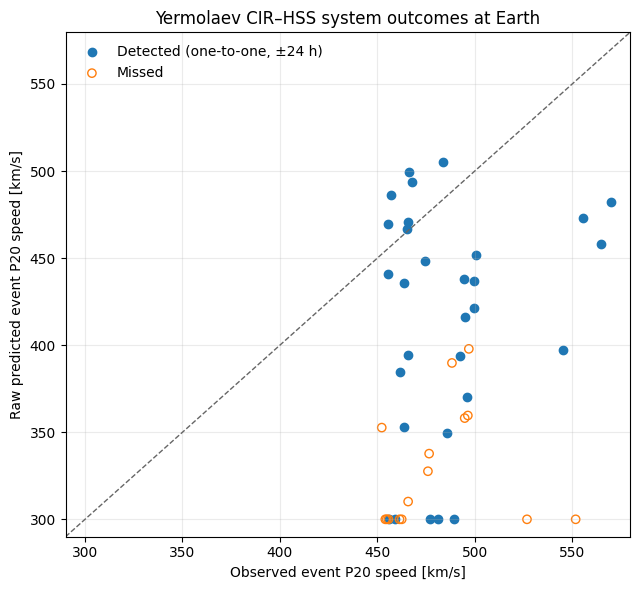

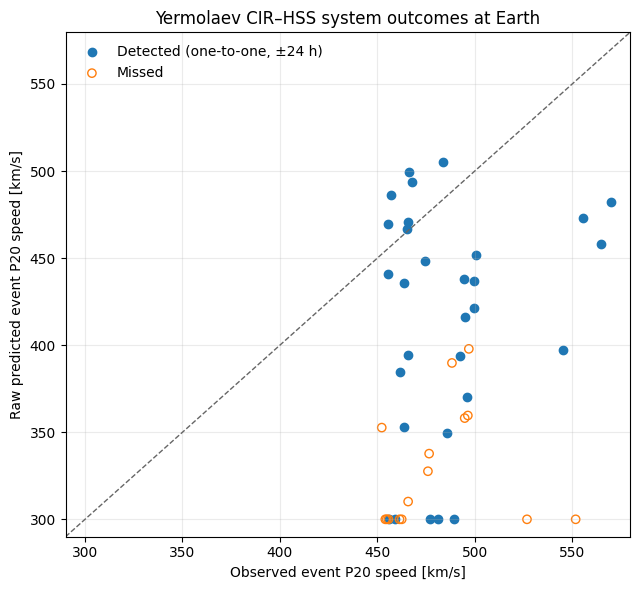

In [13]:
figure, axis = plt.subplots(figsize=(6.5, 6.0))

detected_mask = event_results["detected_with_tolerance"]
axis.scatter(
    event_results.loc[detected_mask, "v_observed_p20"],
    event_results.loc[detected_mask, "v_predict_raw_p20"],
    color="tab:blue",
    label=f"Detected (one-to-one, ±{DETECTION_TOLERANCE_HOURS} h)",
)
axis.scatter(
    event_results.loc[~detected_mask, "v_observed_p20"],
    event_results.loc[~detected_mask, "v_predict_raw_p20"],
    facecolors="none",
    edgecolors="tab:orange",
    label="Missed",
)

plot_values = event_results[["v_observed_p20", "v_predict_raw_p20"]].to_numpy()
plot_min = np.nanmin(plot_values) - 10
plot_max = np.nanmax(plot_values) + 10
axis.plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    color="0.4",
    linestyle="--",
    linewidth=1,
)
axis.set(
    xlim=(plot_min, plot_max),
    ylim=(plot_min, plot_max),
    xlabel="Observed event P20 speed [km/s]",
    ylabel="Raw predicted event P20 speed [km/s]",
    title="Yermolaev CIR–HSS system outcomes at Earth",
)
axis.grid(alpha=0.25)
axis.legend(frameon=False)
figure.tight_layout()
figure


### Contrast detections and misses

This compact table keeps the detection-conditioned bias separate from miss severity and shows whether duration or the 300 km/s model floor concentrates in either outcome.


In [14]:
outcome_summary = (
    event_results.groupby("outcome", as_index=False)
    .agg(
        events=("event_id", "size"),
        cir_associated_events=("cir_associated", "sum"),
        median_event_envelope_hours=("event_envelope_hours", "median"),
        median_fast_hours=("catalog_fast_hours", "median"),
        median_observed_p20=("v_observed_p20", "median"),
        median_predicted_p20=("v_predict_raw_p20", "median"),
        mean_p20_shortfall=("p20_underprediction_kms", "mean"),
        median_p20_shortfall=("p20_underprediction_kms", "median"),
        floor_only_events=("v_predict_raw_max", lambda values: values.eq(300.0).sum()),
    )
)
outcome_summary


,outcome,events,cir_associated_events,median_event_envelope_hours,median_fast_hours,median_observed_p20,median_predicted_p20,mean_p20_shortfall,median_p20_shortfall,floor_only_events
0,detected,30,21,56.0,42.5,479.216143,436.316154,72.271742,77.387999,1
1,missed,15,8,30.0,19.0,475.960924,310.194227,152.032777,154.085000,6


## Takeaways

- A leading `CIR → [IS/ISa] → SWfast` sequence now expands the following HSS event envelope; CIR remains a separator and never joins the preceding fast stream to the following one.
- Of 61 catalog events, 31 have a leading CIR. Among eligible events, 21 of 29 CIR-associated systems are detected (72.4%), while overall one-to-one matching still detects 30 of 45 systems (66.7%).
- The expanded definition does not change any of the 30 one-to-one assignments in 2018: the ±24-hour tolerance had already selected the same predicted streams. It does make 26 detections direct event-envelope overlaps, leaving only 4 recovered solely by tolerance.
- For detected CIR-associated systems, the modeled 450 km/s onset is a median 1 hour before the catalog CIR start; 6 threshold onsets fall inside the catalogued CIR interval.
- P20 remains a same-window `SWfast`-only amplitude metric. Detected events have a mean/median underprediction of 72.3/77.4 km/s; missed events have a mean/median shortfall of 152.0/154.1 km/s, and 6 of the 15 misses remain at the 300 km/s floor.
